In [ ]:
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import LeaveOneOut,KFold,train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, r2_score
import matplotlib.pyplot as plt
from itertools import product

In [14]:
data = pd.read_excel('Microwave_Pyrolysis_Dataset.xlsx')
data = data.drop(columns=['No.','Biomass','Catalyst','Ref'])

#train_data,test_data = train_test_split(data,test_size = 0.2,random_state = 42
                            #            )

In [16]:
X= data.drop(['Gas yield', 'Char yield', 'Oil yield'], axis = 1 , inplace= False)
y = data['Char yield']

# x_cv= test_data.drop(['Gas yield', 'Char yield', 'Oil yield'], axis = 1 , inplace= False)
# y_cv = test_data['Char yield']

In [17]:
parameter = {
    'n_estimators': [50,100],
    'max_depth':[10,23],
    'min_sample_split': [2,5],
    'min_sample_leaf':[1,5]
}

#the product give teh iterator with all the combunation... we cahnge it to list
para_combinations = list(product(parameter['n_estimators'],parameter['max_depth'],parameter['min_sample_split'],parameter['min_sample_leaf']
))

best_mse = float('inf')
best_para = None
max_depth_hist = []
mse_mean = []

for n_estimators,max_depth,min_samples_split,min_samples_leaf in para_combinations:
  model = RandomForestRegressor(
      n_estimators = n_estimators,max_depth= max_depth,
                                min_samples_split=min_samples_split,
                                min_samples_leaf=min_samples_leaf,
                                random_state=1)

  #loo = LeaveOneOut()
  loo= KFold(n_splits=5,random_state=1,shuffle=True)
  mse_hist = []

  for train_ind,test_ind in loo.split(y):
    x_train,y_train,x_test,y_test= X.iloc[train_ind],y.iloc[train_ind],X.iloc[test_ind],y.iloc[test_ind]

    model.fit(x_train,y_train)
    mse = mean_squared_error(model.predict(x_test),y_test)
    mse_hist.append(mse)

  mse_mean.append(np.mean(mse_hist))
  max_depth_hist.append(max_depth)


  if mse < best_mse:
    best_mse = mse
    best_para= {
        'max_depth':max_depth,
        'min_samples_split': min_samples_split,
        'min_samples_leaf':min_samples_leaf

    }



{'max_depth': 10, 'min_samples_split': 2, 'min_samples_leaf': 1}
Mean Squared error:20.721052343493938
Mean Abs err:2.772240214512221
R2 score : 0.9114781988316385


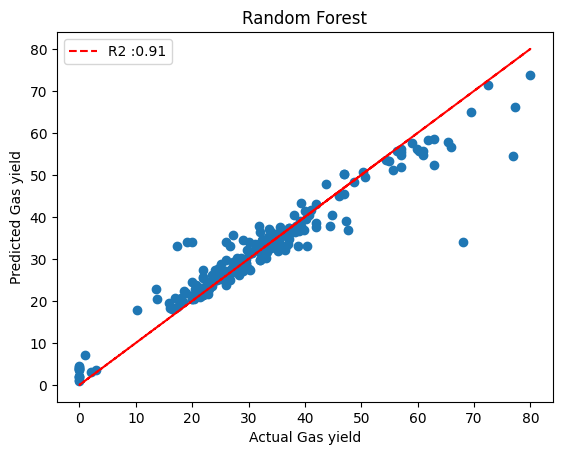

In [20]:

best_model = RandomForestRegressor(**best_para,
                                    random_state =42)
#n_estimators= 100,
#max_depth= 10,
#min_samples_split= 2,
#min_samples_leaf= 1

loo = LeaveOneOut()
y_hist= []
ypred_hist = []
#
#or train_idx,test_idx in loo.split(y):
  #x_train, y_train,x_test,y_test = X.iloc[train_idx],y.iloc[train_idx],X.iloc[test_idx],y.iloc[test_idx]
best_model.fit(X,y)

y_pred = best_model.predict(X)

#mae = mean_absolute_error(y_pred,y)
#mape = mean_absolute_percentage_error(y_pred,y)



mse = mean_squared_error(y,y_pred)
mae = mean_absolute_error(y,y_pred)
r2 = r2_score(y,y_pred)
print(best_para)
print(f'Mean Squared error:{mse}')
print(f'Mean Abs err:{mae}')
#print(f'Mean Abs er per: {mape}')
print(f'R2 score : {r2}')

#max_depth = np.max(best_model.get_depth())
#print(f'Max depthd the trees: {max_depth}')
#print(f'Number of Estimators :{len(best_model.estimators_)}')

# plt.subplot(1,2,1)
# plt.plot(mse_mean,max_depth_hist,'b--',label = 'MSE')
# plt.subplot(1,2,2)
plt.plot(y,y,'r--',label= 'Ideal')
plt.scatter(y,y_pred,label='Predicted')
plt.xlabel('Actual Gas yield')
plt.ylabel('Predicted Gas yield')
plt.title('Random Forest')
plt.legend([f'R2 :{r2:0.2f}'])
plt.show()


